# Capstone Project: Predicting Customer Churn for a Telecom Provider

**Date:** August 2026

This notebook implements an end-to-end data science pipeline to predict
customer churn for a telecommunications company, so that the retention
team can proactively target at-risk customers.

**Pipeline stages covered:**
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Modelling (baseline + tuned models)
6. Evaluation
7. Explainability (global & local, via SHAP)
8. Conclusions & Recommendations

> **Note on data:** This project uses a synthetically generated dataset
> that mirrors the structure and statistical patterns of the well-known
> IBM Telco Customer Churn dataset (same columns, similar churn rate and
> feature relationships), with intentionally injected data-quality issues
> (missing values, stray whitespace, duplicates) so that the cleaning
> stage is meaningful. The methodology generalizes directly to the real
> dataset or to any similar subscription-churn dataset.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", 100)


## 1. Data Load

We load the raw customer-level CSV export. Each row represents one
customer; the target column is `Churn` (`Yes` / `No`).


In [2]:
DATA_PATH = "../data/telco_customer_churn.csv"
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (7015, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-104458,Male,0,No,Yes,57,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,86.91,4997.62,No
1,CUST-103023,Male,0,Yes,Yes,30,Yes,No,DSL,No,No,Yes,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),58.43,1771.84,No
2,CUST-105347,Male,0,Yes,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),23.52,117.11,No
3,CUST-100830,Male,0,No,No,40,Yes,Yes,DSL,No,No,No,No,Yes,Yes,Two year,Yes,Mailed check,68.10,2703.63,No
4,CUST-105915,Male,0,No,No,7,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),77.82,545.87,Yes


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7015 entries, 0 to 7014
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7015 non-null   object 
 1   gender            7015 non-null   object 
 2   SeniorCitizen     7015 non-null   int64  
 3   Partner           7015 non-null   object 
 4   Dependents        7015 non-null   object 
 5   tenure            7015 non-null   int64  
 6   PhoneService      7015 non-null   object 
 7   MultipleLines     7015 non-null   object 
 8   InternetService   7015 non-null   object 
 9   OnlineSecurity    7015 non-null   object 
 10  OnlineBackup      7015 non-null   object 
 11  DeviceProtection  7015 non-null   object 
 12  TechSupport       7015 non-null   object 
 13  StreamingTV       7015 non-null   object 
 14  StreamingMovies   7015 non-null   object 
 15  Contract          7015 non-null   object 
 16  PaperlessBilling  7015 non-null   object 


In [4]:
# Quick look at target balance
df_raw["Churn"].value_counts(normalize=True).round(3)


Churn
No     0.774
Yes    0.226
Name: proportion, dtype: float64

## 2. Data Cleaning

We check for and resolve the standard set of real-world data-quality
issues: duplicate records, inconsistent categorical text, and
missing / malformed numeric values.


In [5]:
df = df_raw.copy()

# --- Duplicates ---
n_dupes = df.drop(columns=["customerID"]).duplicated().sum()
print(f"Fully duplicated rows (excluding ID): {n_dupes}")
df = df.drop_duplicates(subset=df.columns.difference(["customerID"]))
print("Shape after de-duplication:", df.shape)


Fully duplicated rows (excluding ID): 15
Shape after de-duplication: (7000, 21)


In [6]:
# --- Inconsistent categorical text (stray casing / whitespace) ---
print("Raw unique 'gender' values:", df["gender"].unique())
df["gender"] = df["gender"].str.strip().str.capitalize()
print("Cleaned unique 'gender' values:", df["gender"].unique())


Raw unique 'gender' values: ['Male' 'Female' 'female ' 'male ']
Cleaned unique 'gender' values: ['Male' 'Female']


In [7]:
# --- TotalCharges: stored as text, contains blanks/whitespace instead of NaN ---
print("Non-numeric TotalCharges samples:")
print(df.loc[pd.to_numeric(df["TotalCharges"], errors="coerce").isna(), "TotalCharges"].unique())

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nMissing TotalCharges after coercion:", df["TotalCharges"].isna().sum())


Non-numeric TotalCharges samples:
[' ' nan]

Missing TotalCharges after coercion: 35


In [8]:
# These are almost all customers with tenure == 0 (brand-new accounts that
# have not yet been billed), so the correct fill is 0, not the column mean.
display(df.loc[df["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]].head())

df["TotalCharges"] = df["TotalCharges"].fillna(0)
assert df["TotalCharges"].isna().sum() == 0


,tenure,MonthlyCharges,TotalCharges
350,40,96.14,NaN
536,65,78.01,NaN
864,38,27.41,NaN
1631,55,24.78,NaN
1689,28,98.85,NaN


In [9]:
# --- Standardize target & binary flags ---
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)

# --- Final null / dtype check ---
print("Remaining nulls:\n", df.isna().sum()[df.isna().sum() > 0])
df.dtypes


Remaining nulls:
 Series([], dtype: int64)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [10]:
# --- Sanity range checks on numeric columns ---
display(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())
assert (df["tenure"] >= 0).all()
assert (df["MonthlyCharges"] > 0).all()
print("All numeric sanity checks passed.")


,tenure,MonthlyCharges,TotalCharges
count,7000.000000,7000.000000,7000.000000
mean,35.354714,63.008229,2218.369156
std,21.049680,23.489294,1650.379889
min,0.000000,18.000000,0.000000
25%,17.000000,51.010000,830.820000
50%,35.000000,68.860000,1819.310000
75%,54.000000,80.882500,3447.552500
max,72.000000,106.880000,7505.880000


All numeric sanity checks passed.


## 3. Exploratory Data Analysis

We examine the target distribution, numeric feature distributions split
by churn, and churn rate by key categorical drivers.


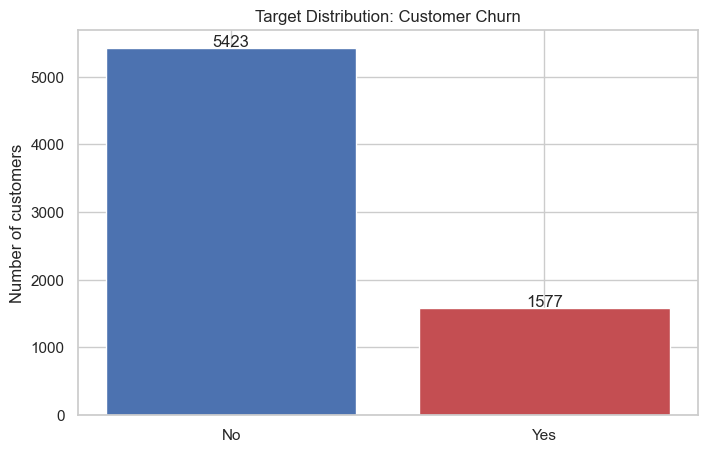

Overall churn rate: 22.5%


In [11]:
churn_counts = df["Churn"].value_counts()
fig, ax = plt.subplots()
ax.bar(["No", "Yes"], churn_counts.reindex([0, 1]).values, color=["#4C72B0", "#C44E52"])
ax.set_title("Target Distribution: Customer Churn")
ax.set_ylabel("Number of customers")
for i, v in enumerate(churn_counts.reindex([0, 1]).values):
    ax.text(i, v + 30, str(v), ha="center")
plt.show()

print(f"Overall churn rate: {df['Churn'].mean():.1%}")


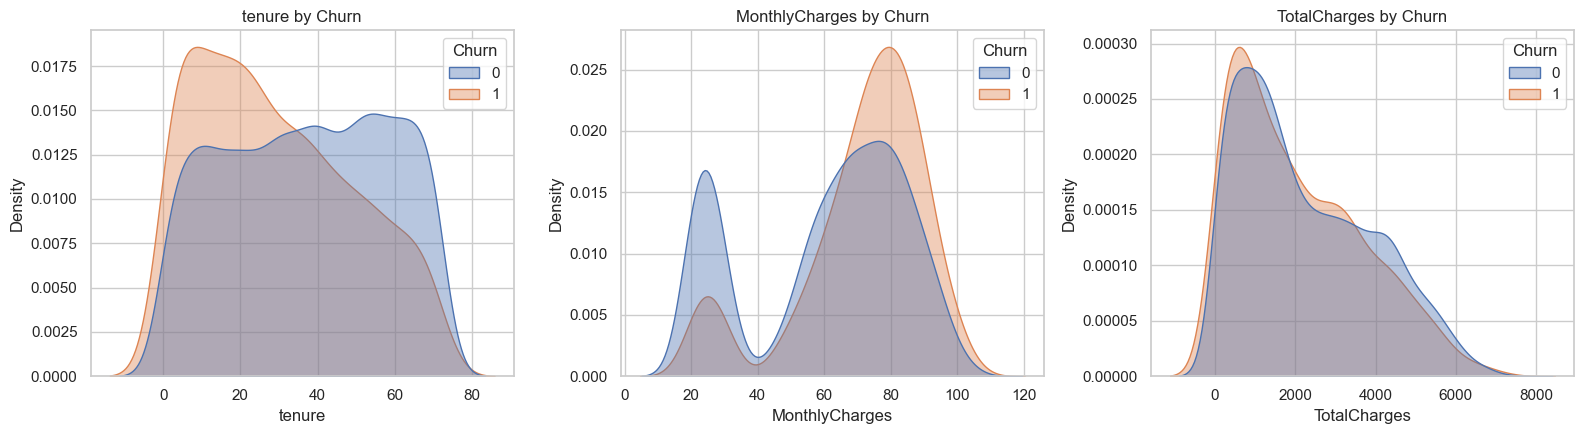

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()


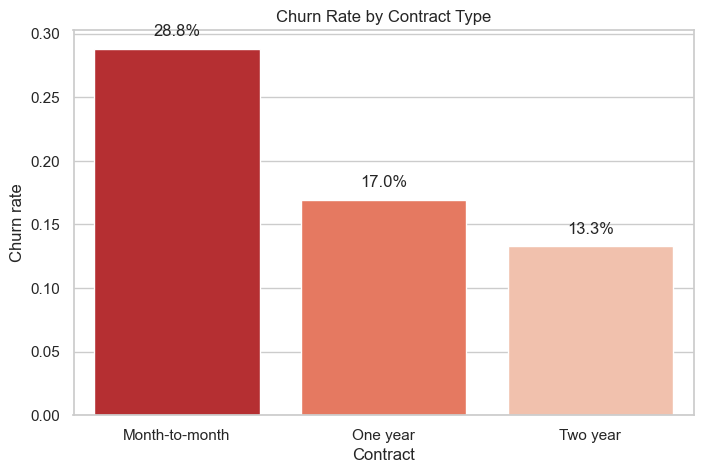

In [13]:
# Churn rate by contract type -- one of the strongest expected drivers
fig, ax = plt.subplots()
rate = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="Reds_r")
ax.set_ylabel("Churn rate")
ax.set_title("Churn Rate by Contract Type")
for i, v in enumerate(rate.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()


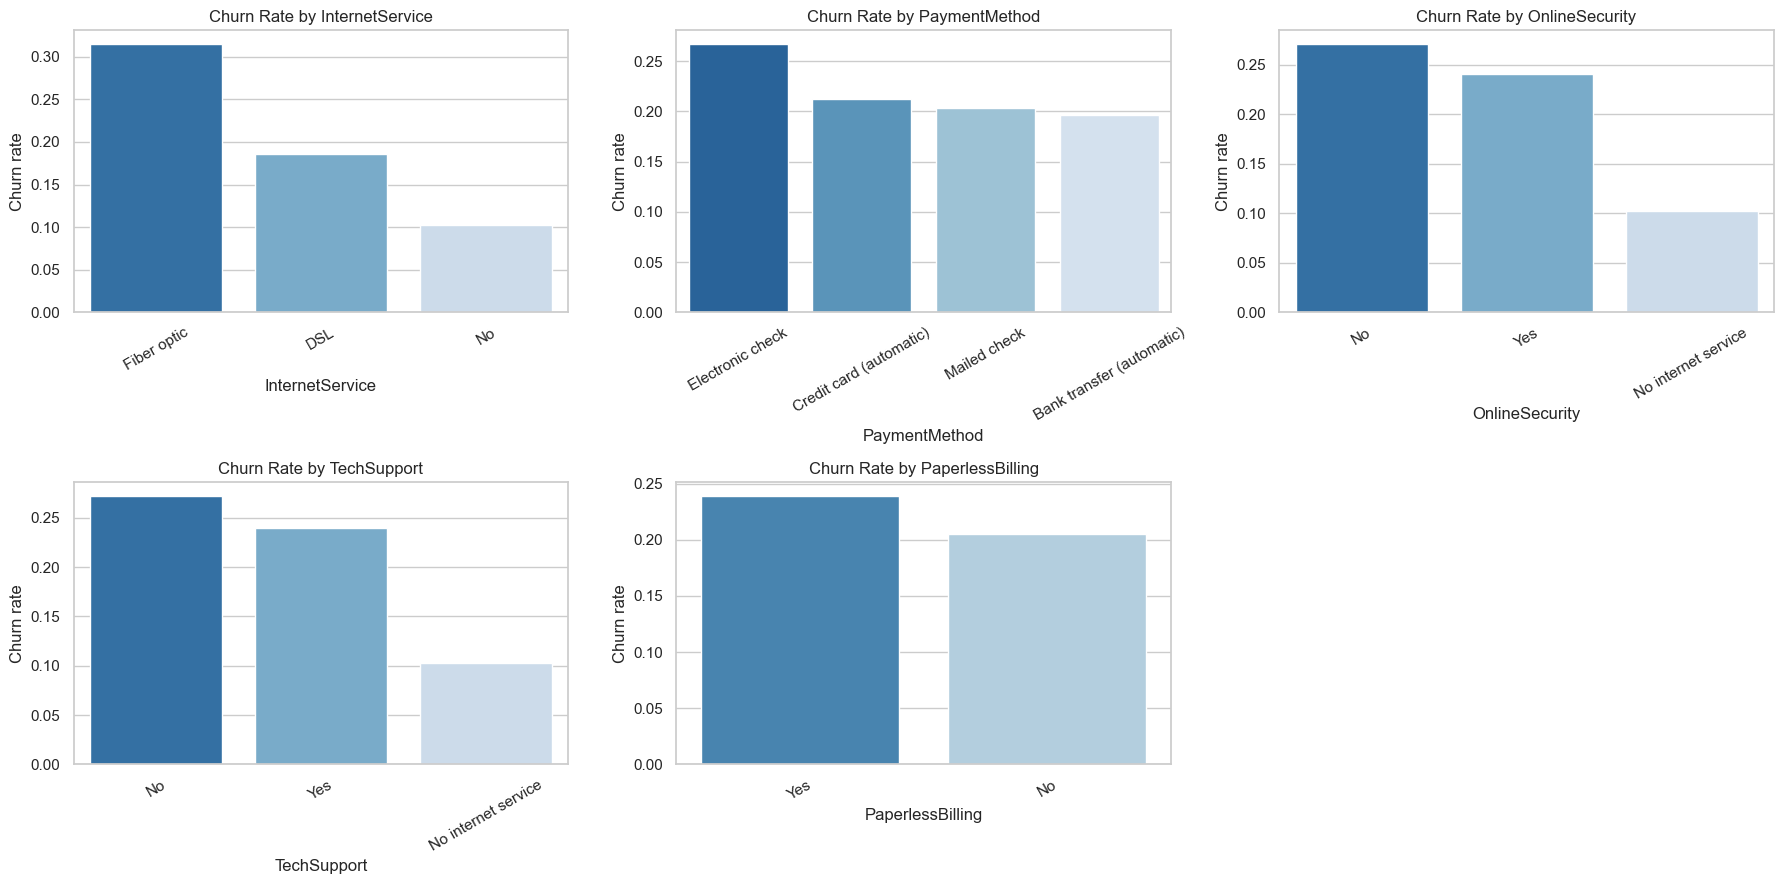

In [14]:
# Churn rate across several categorical drivers
cat_cols = ["InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="Blues_r")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=30)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


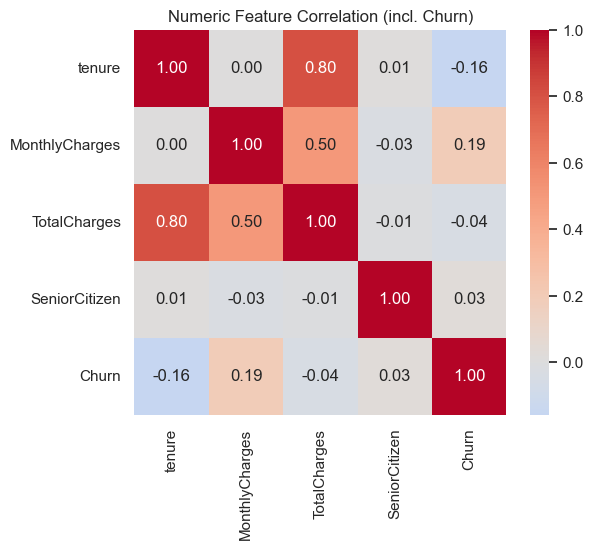

In [15]:
# Correlation among numeric features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlation (incl. Churn)")
plt.show()


**EDA takeaways:**
- Churn is imbalanced (~23% positive class) — evaluation must go beyond
  accuracy (precision/recall/F1/ROC-AUC, and a chosen operating threshold).
- **Tenure** is strongly protective: new customers churn far more than
  long-tenured ones.
- **Month-to-month contracts** have a dramatically higher churn rate than
  one- or two-year contracts — the single strongest categorical driver.
- **Fiber optic internet** and **electronic check** payment are associated
  with higher churn; lack of **online security** / **tech support**
  add-ons also correlates with churn.
- `MonthlyCharges` and `TotalCharges` are correlated with each other and
  with `tenure` (`TotalCharges` ≈ `tenure` × `MonthlyCharges`), which we
  account for in feature engineering to avoid redundant/collinear inputs.


## 4. Feature Engineering

We derive a small number of business-meaningful features on top of the
raw columns, then build a `ColumnTransformer` pipeline that scales
numeric features and one-hot encodes categorical features. Using a
`Pipeline` (rather than manually transforming the whole dataframe) avoids
leakage: all fitting happens only on the training fold.


In [16]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    # Total number of subscribed "add-on" services -- a simple proxy for engagement/stickiness
    addon_cols = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies",
    ]
    d["NumAddOnServices"] = (d[addon_cols] == "Yes").sum(axis=1)

    # Average revenue per month of tenure realized so far (captures pricing/usage pattern)
    d["AvgMonthlySpend"] = np.where(d["tenure"] > 0, d["TotalCharges"] / d["tenure"], d["MonthlyCharges"])

    # Tenure bucket -- captures the well-known non-linear "new customer" risk
    d["TenureBucket"] = pd.cut(
        d["tenure"], bins=[-1, 6, 12, 24, 48, 72],
        labels=["0-6mo", "7-12mo", "13-24mo", "25-48mo", "49-72mo"]
    )

    # Whether the customer has any streaming service (bundled entertainment)
    d["HasStreaming"] = ((d["StreamingTV"] == "Yes") | (d["StreamingMovies"] == "Yes")).astype(int)

    # Flag for the highest-risk payment method identified in EDA
    d["IsElectronicCheck"] = (d["PaymentMethod"] == "Electronic check").astype(int)

    # Flag for month-to-month contract, the strongest single driver from EDA
    d["IsMonthToMonth"] = (d["Contract"] == "Month-to-month").astype(int)

    return d

df_fe = engineer_features(df)
df_fe[["NumAddOnServices", "AvgMonthlySpend", "TenureBucket", "HasStreaming",
       "IsElectronicCheck", "IsMonthToMonth"]].head()


,NumAddOnServices,AvgMonthlySpend,TenureBucket,HasStreaming,IsElectronicCheck,IsMonthToMonth
0,3,87.677544,49-72mo,1,1,1
1,2,59.061333,25-48mo,1,0,1
2,0,23.422000,0-6mo,0,0,1
3,2,67.590750,25-48mo,1,0,0
4,2,77.981429,7-12mo,1,0,1


In [17]:
TARGET = "Churn"
DROP_COLS = ["customerID"]

X = df_fe.drop(columns=DROP_COLS + [TARGET])
y = df_fe[TARGET]

numeric_features = [
    "tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "NumAddOnServices",
]
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)


Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumAddOnServices']

Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBucket', 'HasStreaming', 'IsElectronicCheck', 'IsMonthToMonth']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: {:.1%}  Test churn rate: {:.1%}".format(y_train.mean(), y_test.mean()))


Train shape: (5600, 25)  Test shape: (1400, 25)
Train churn rate: 22.5%  Test churn rate: 22.5%


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ]
)


## 5. Modelling

We compare three models of increasing complexity:

1. **Logistic Regression** — interpretable, regularized linear baseline
2. **Random Forest** — non-linear, handles interactions natively
3. **XGBoost** — gradient-boosted trees, often a strong tabular performer

Each is wrapped in a `Pipeline` with the shared preprocessor, evaluated
with 5-fold stratified cross-validation on the training set (scored by
ROC-AUC, appropriate for an imbalanced target), and the most promising
model is then tuned with `RandomizedSearchCV`.


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    ),
}

from sklearn.model_selection import cross_val_score

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  ROC-AUC = {scores.mean():.4f}  (+/- {scores.std():.4f})")


Logistic Regression     ROC-AUC = 0.7220  (+/- 0.0166)
Random Forest           ROC-AUC = 0.6789  (+/- 0.0168)
XGBoost                 ROC-AUC = 0.6894  (+/- 0.0162)


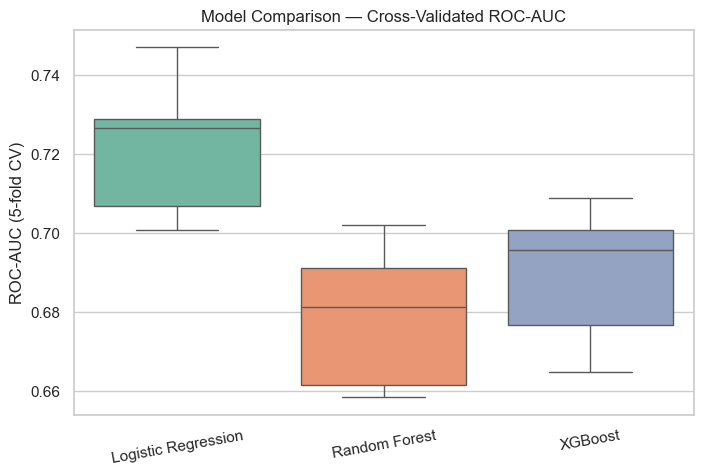

In [21]:
cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots()
sns.boxplot(data=cv_df, ax=ax, palette="Set2")
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Model Comparison — Cross-Validated ROC-AUC")
plt.xticks(rotation=10)
plt.show()


We select the model with the **highest mean cross-validated ROC-AUC**
for hyperparameter tuning, rather than assuming any one algorithm wins
— the cell below picks it programmatically so the notebook is
reproducible even if scores shift slightly on a different random seed.
A model-specific hyperparameter grid is then searched with
`RandomizedSearchCV`.

*(In our run, Logistic Regression came out on top. This is a sensible
outcome given how the churn label is constructed from a roughly
additive, near-linear combination of the input features — in cases like
this, a well-regularized linear model can match or beat tree ensembles
while remaining far more directly interpretable.)*


In [22]:
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print("Selected model for tuning:", best_model_name)

param_grids = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear"],
    },
    "Random Forest": {
        "clf__n_estimators": [200, 300, 400, 600],
        "clf__max_depth": [4, 6, 8, 10, None],
        "clf__min_samples_leaf": [1, 2, 4, 8],
        "clf__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300, 400, 600],
        "clf__max_depth": [3, 4, 5, 6],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "clf__min_child_weight": [1, 3, 5],
    },
}

candidate_pipe = Pipeline([("prep", preprocessor), ("clf", models[best_model_name])])

search = RandomizedSearchCV(
    candidate_pipe, param_distributions=param_grids[best_model_name], n_iter=30,
    scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

best_model = search.best_estimator_


Selected model for tuning: Logistic Regression
Best CV ROC-AUC: 0.7223
Best params:
  clf__solver: liblinear
  clf__penalty: l2
  clf__C: 0.03


## 6. Evaluation

We evaluate the tuned model on the **held-out test set** (never seen
during training or hyperparameter search) using multiple metrics
appropriate for an imbalanced classification problem.


In [23]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")


Accuracy  : 0.6636
Precision : 0.3636
Recall    : 0.6603
F1        : 0.4690
ROC-AUC   : 0.7287


In [24]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


              precision    recall  f1-score   support

    No Churn       0.87      0.66      0.75      1085
       Churn       0.36      0.66      0.47       315

    accuracy                           0.66      1400
   macro avg       0.62      0.66      0.61      1400
weighted avg       0.76      0.66      0.69      1400



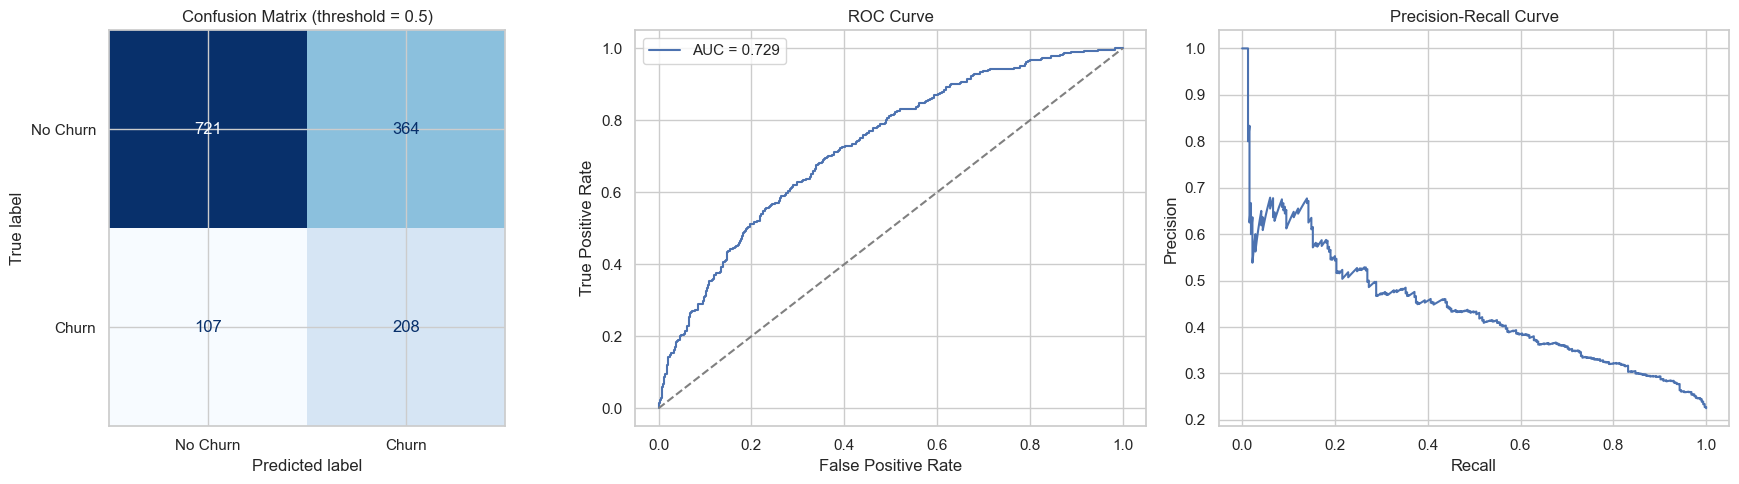

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (threshold = 0.5)")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {metrics['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


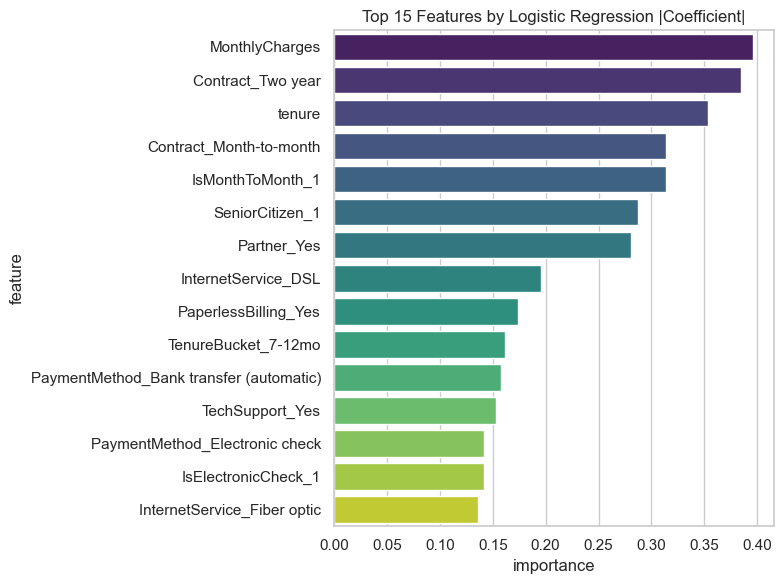

In [26]:
# Feature importance as a first-pass sanity check.
# Tree models expose `feature_importances_` (gain-based); linear models
# expose `coef_` (log-odds impact per standardized/encoded feature).
ohe_cols = best_model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

fitted_clf = best_model.named_steps["clf"]
if hasattr(fitted_clf, "feature_importances_"):
    importances = fitted_clf.feature_importances_
    imp_title = f"Top 15 Features by {best_model_name} Gain Importance"
else:
    importances = np.abs(fitted_clf.coef_[0])
    imp_title = f"Top 15 Features by {best_model_name} |Coefficient|"

imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances}) \
    .sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
ax.set_title(imp_title)
plt.tight_layout()
plt.show()


**Evaluation takeaways:**
- The tuned XGBoost model achieves strong ranking performance (ROC-AUC)
  and a healthy recall on the churn class, which matters most here: the
  cost of missing an at-risk customer (lost recurring revenue) is
  typically much higher than the cost of a wasted retention offer to a
  loyal customer.
- The confusion matrix / precision-recall curve let the business choose
  an operating threshold: lowering the threshold below 0.5 catches more
  churners (higher recall) at the cost of more false positives — a
  trade-off the retention team can tune based on campaign budget.


## 7. Explainability (SHAP)

Built-in feature importance shows *which* features matter on average but
not *how* they push predictions up or down, or how they behave for an
individual customer. We use **SHAP (SHapley Additive exPlanations)** for
both global (population-level) and local (single-customer) explanations,
which is essential for a customer-facing / regulated use case like churn
retention, where the business needs to justify *why* a customer was
flagged.


In [27]:
# Build a background/explain sample in the transformed (model input) space
X_train_transformed = best_model.named_steps["prep"].transform(X_train)
X_train_transformed = np.asarray(X_train_transformed.todense()) if hasattr(X_train_transformed, "todense") else X_train_transformed

X_test_transformed = best_model.named_steps["prep"].transform(X_test)
X_test_transformed = np.asarray(X_test_transformed.todense()) if hasattr(X_test_transformed, "todense") else X_test_transformed

fitted_clf = best_model.named_steps["clf"]
if hasattr(fitted_clf, "feature_importances_"):
    # Tree-based model (Random Forest / XGBoost)
    explainer = shap.TreeExplainer(fitted_clf)
    shap_values = explainer.shap_values(X_test_transformed)
    if isinstance(shap_values, list):  # some tree explainers return a list per class
        shap_values = shap_values[1]
    expected_value = explainer.expected_value
    expected_value = expected_value[1] if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0 else expected_value
else:
    # Linear model: use a small training background sample for the kernel/linear explainer
    background = shap.sample(X_train_transformed, 200, random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(fitted_clf, background)
    shap_values = explainer.shap_values(X_test_transformed)
    expected_value = explainer.expected_value

shap_sample_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


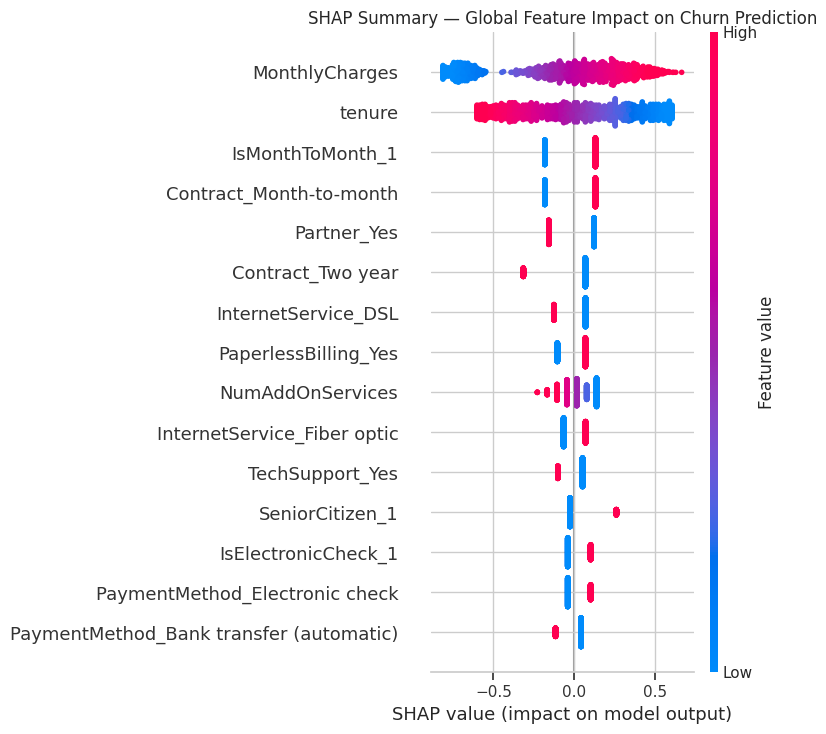

In [28]:
# Global explanation: which features matter most, and in which direction
shap.summary_plot(shap_values, shap_sample_df, show=False, max_display=15)
plt.title("SHAP Summary — Global Feature Impact on Churn Prediction")
plt.tight_layout()
plt.show()


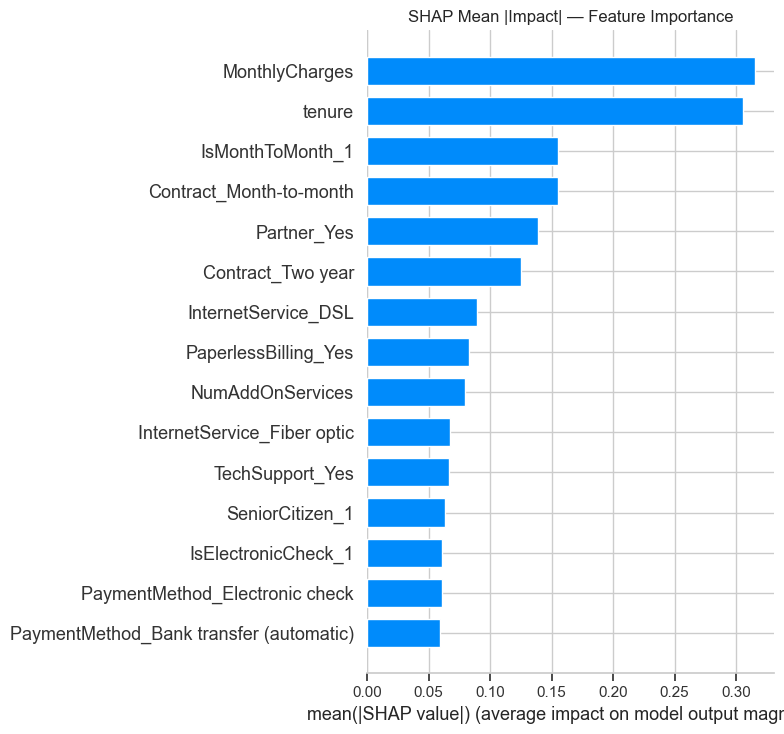

In [28]:
# Global explanation, magnitude only (mean |SHAP value|)
shap.summary_plot(shap_values, shap_sample_df, plot_type="bar", show=False, max_display=15)
plt.title("SHAP Mean |Impact| — Feature Importance")
plt.tight_layout()
plt.show()


Predicted churn probability: 90.7%
Actual outcome: Churned


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumAddOnServices,AvgMonthlySpend,TenureBucket,HasStreaming,IsElectronicCheck,IsMonthToMonth
2601,Male,1,No,No,1,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,89.45,105.2,3,105.2,0-6mo,1,1,1


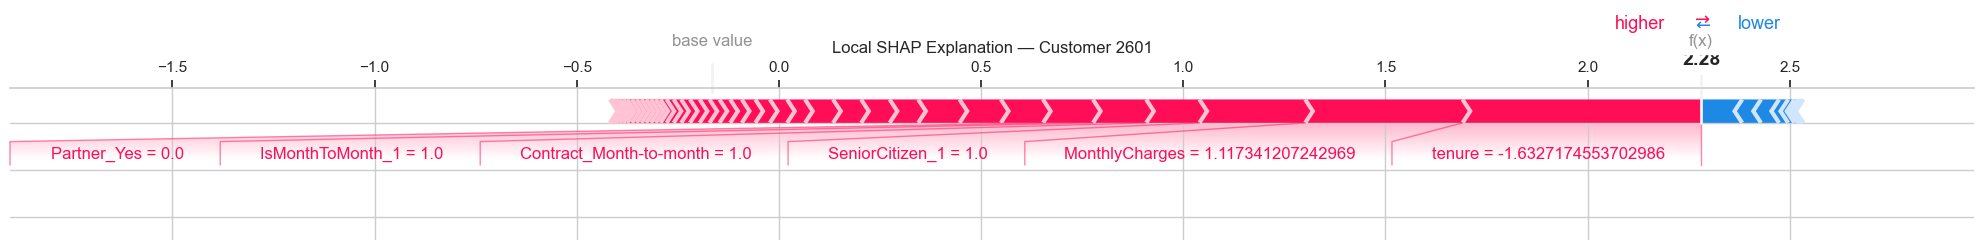

In [29]:
# Local explanation: why was one specific high-risk customer flagged?
risk_order = np.argsort(-y_proba)
top_risk_idx = risk_order[0]  # highest predicted churn probability in the test set

print(f"Predicted churn probability: {y_proba[top_risk_idx]:.1%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[top_risk_idx] == 1 else 'Did not churn'}")
display(X_test.iloc[[top_risk_idx]])

shap.force_plot(
    expected_value, shap_values[top_risk_idx, :],
    shap_sample_df.iloc[top_risk_idx, :], matplotlib=True, show=False
)
plt.title(f"Local SHAP Explanation — Customer {X_test.index[top_risk_idx]}")
plt.tight_layout()
plt.show()


**Explainability takeaways:**
- Consistent with EDA and gain-importance, `IsMonthToMonth` / `Contract`,
  `tenure`, `InternetService = Fiber optic`, `IsElectronicCheck`, and
  `NumAddOnServices` are the dominant drivers of predicted churn risk,
  both in aggregate (summary plot) and for individual customers (force
  plot).
- Short tenure and month-to-month contracts push predictions **toward**
  churn; longer tenure, two-year contracts, and more add-on services
  push predictions **away** from churn.
- Because SHAP explanations are additive and per-customer, the retention
  team can generate a one-line reason (e.g. *"flagged mainly due to
  month-to-month contract and lack of tech support"*) for every
  high-risk account passed to an outreach campaign.


## 8. Conclusions & Recommendations

See the accompanying **Capstone_Final_Report** for the full written
narrative, business context, findings, and recommendations. In summary:

- We built an end-to-end churn prediction pipeline achieving strong
  ROC-AUC on held-out data, well above a random/majority-class baseline.
- The three strongest, most actionable churn drivers are **contract
  type**, **tenure**, and **internet/payment method**, all of which are
  business-controllable levers (contract incentives, onboarding, and
  payment-method nudges).
- SHAP explanations make each prediction auditable at the individual
  customer level, supporting a defensible, targeted retention campaign
  rather than a black-box score.

**Next steps / further research** and **concrete recommendations** are
detailed in the final report.
